In [1]:
import numpy as np
import matplotlib.patches as mpatches
from matplotlib import gridspec
import os
import glob
from pyproj import Proj, Transformer
from scipy.spatial.kdtree import KDTree
import datetime
import pandas as pd
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import math
from scipy.stats import linregress
import itertools
np.float=float
import cartopy.crs as ccrs
import cartopy
from matplotlib.colors import LinearSegmentedColormap

/var/folders/_1/fh2vf5m57871c546k_sf7xr80000gn/T/ipykernel_3616/181293386.py:7: DeprecationWarning: Please use `KDTree` from the `scipy.spatial` namespace, the `scipy.spatial.kdtree` namespace is deprecated.
  from scipy.spatial.kdtree import KDTree


In [2]:
months = np.arange(1,13)
years = np.arange(2011,2022)

In [3]:
def lonlat_to_xy(coords_1, coords_2, hemisphere, inverse=False):

    """Converts between longitude/latitude and EASE xy coordinates.
 
    Args:
        lon (float): WGS84 longitude
        lat (float): WGS84 latitude
        hemisphere (string): 'n' or 's'
        inverse (bool): if true, converts xy to lon/lat
 
    Returns:
        tuple: pair of xy or lon/lat values
    """

    EASE_Proj = {'n': 'EPSG:3408',
                 's': 'EPGS:3409'}
    
    WGS_Proj = 'EPSG:4326'
    
    for coords in [coords_1, coords_2]: assert isinstance(coords,(np.ndarray,list))

    if inverse == False: # lonlat to xy
        
        lon, lat = coords_1, coords_2
        
        transformer = Transformer.from_crs(WGS_Proj, EASE_Proj[hemisphere])
        
        x, y = transformer.transform(lat, lon)
        
        return (x, y)

    else: # xy to lonlat
        
        x, y = coords_1, coords_2
        
        transformer = Transformer.from_crs(EASE_Proj[hemisphere], WGS_Proj)
        
        lat, lon = transformer.transform(x, y)
        
        return (lon, lat)

### data prep

In [4]:
df_all = pd.read_csv('/Users/carmennab/Dropbox/pb_new/data/bears/data_combined.csv').sort_values(['ID','date'])

df_all['month'] = [int(date[5:7]) for date in df_all['date']]
df_all['year'] = [int(date[0:4]) for date in df_all['date']]
df_all['datetime'] = [datetime.datetime.strptime(f'{date} {time}', '%Y-%m-%d %H:%M:%S') for date,time in 
                      zip(df_all['date'],df_all['time'])]

In [5]:
### group 1 = adult females, group 2 = adult males, group 3 = subadult
group = []
for age, sex in zip(df_all['age'],df_all['sex']):
    if (age == 'Adult') & (sex == 'F'):
        group.append(1)
    elif (age == 'Adult') & (sex == 'M'):
        group.append(2)
    elif (age == 'Subadult'):
        group.append(3)
    else:
        group.append(np.nan)
        
df_all['group'] = group

In [6]:
ice_df = [] ; first_dates = [] ; bears = []
for ID in set(df_all['ID']):
    bear_df = df_all[df_all['ID']==ID]
    for year in set(bear_df['year']):
        year_df = bear_df[(bear_df['year']==year)&(np.isin(bear_df['month'],[11,12]))]
        on_ice = year_df[year_df['SIT']>0].sort_values('datetime')
        if len(on_ice)>0:
            ### date for first day on ice
            first_date = on_ice['datetime'].iloc[0]
            first_dates.append(first_date.strftime('%Y%m%d'))
            bears.append(bear_df['group'].iloc[0])

            days_on_ice = [(date - first_date).days+1 for date in year_df['datetime']]

            year_df['days_on_ice'] = days_on_ice

            ice = year_df[(year_df['days_on_ice']>-20)&(year_df['days_on_ice']<51)]

            for row in np.arange(0,len(ice)):
                ice_df.append(ice.iloc[row])            

ice_df = pd.DataFrame(ice_df)

### plot figure

SIT 1 MIN = 0.02, MEAN = 0.08, MAX = 0.47
SIT 2 MIN = 0.02, MEAN = 0.12, MAX = 0.96
SIT 3 MIN = 0.02, MEAN = 0.19, MAX = 0.96
SIC 1 MIN = 0.40, MEAN = 27.67, MAX = 102.00
SIC 2 MIN = 2.00, MEAN = 35.83, MAX = 100.00
SIC 3 MIN = 0.40, MEAN = 49.81, MAX = 100.00
SD 1 MIN = 0.00, MEAN = 0.02, MAX = 0.14
SD 2 MIN = 0.00, MEAN = 0.02, MAX = 0.08
SD 3 MIN = 0.00, MEAN = 0.02, MAX = 0.04


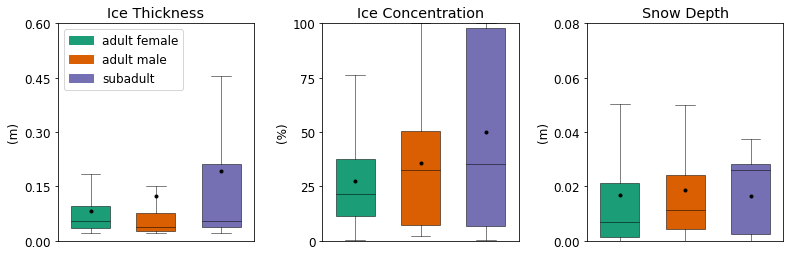

In [7]:
figpath = '/Users/carmennab/Dropbox/Apps/Overleaf/CRiceS_PolarBears_HB/figures/'
fig = plt.figure(figsize=(13,4))
spec = gridspec.GridSpec(ncols=3,nrows=1,wspace=0.35)
plt.rcParams.update({'font.size': 12})

titles = ['Ice Thickness', 'Ice Concentration','Snow Depth']
units = ['(m)','(%)','(m)']
day_df = ice_df[(ice_df['days_on_ice']>0)&(ice_df['days_on_ice']<=7)&(ice_df['d_to_land']<100_000)]
vmins = [0,0,0]
vmaxs = [0.3,0.9,0.09]
xs = [0.122,0.405,0.682]
ymaxs = [0.6,100,0.08]

for c, var in enumerate(['SIT','SIC','SD']):
    
    ### boxplots
    ax1 = fig.add_subplot(spec[c])
    for group,color,y in zip([1,2,3],['#1b9e77','#d95f02','#7570b3'],[0.9,0.82,0.74]):
        df_rad = day_df[(day_df['group']==group)&(day_df[var]>0)]
        if c == 1:
            data_rad = np.multiply(np.array(df_rad[var])[~np.isnan(np.array(df_rad[var]))],100)
        else:
            data_rad = np.array(df_rad[var])[~np.isnan(np.array(df_rad[var]))]
        box = ax1.boxplot(data_rad, positions = [group],widths=0.6, patch_artist=True,
                showfliers=False, showmeans = True,
                medianprops={"color": "black", "linewidth": 0.5},
                meanprops={"markerfacecolor": "black","markeredgecolor": "black", "marker": 'o',"markersize":'3'},
                boxprops={"facecolor": color, "edgecolor": "black",
                          "linewidth": 0.5},
                whiskerprops={"color": "black", "linewidth": 0.5},
                capprops={"color": "black", "linewidth": 0.5})
        data_h = np.hstack(data_rad)
        print(f'{var} {group} MIN = {np.min(data_h):.2f}, MEAN = {np.mean(data_h):.2f}, MAX = {np.max(data_h):.2f}')

    ax1.set_title(titles[c])
    ax1.set_xticks([])
    ax1.set_ylim([0,ymaxs[c]])
    ax1.set_yticks([0,ymaxs[c]/4,ymaxs[c]/2,ymaxs[c]/4+ymaxs[c]/2,ymaxs[c]])
    ax1.set_ylabel(units[c])

    if c == 0:
        af = mpatches.Patch(color='#1b9e77', label='adult female')
        am = mpatches.Patch(color='#d95f02', label='adult male')
        sa = mpatches.Patch(color='#7570b3', label='subadult')
        ax1.legend(loc='upper left',handles=[af,am,sa])
 
# plt.savefig(f'{figpath}min_sit_sd_sic.jpg',bbox_inches = "tight", dpi = 400)

### ice conditions in week before

In [8]:
### calculate distance to land

datapath_aux = '/Users/carmennab/Dropbox/pb_new/auxiliary/'
ease_lons = np.load(f'{datapath_aux}lon_cent.npy')
ease_lats = np.load(f'{datapath_aux}lat_cent.npy')

# convert into x,y:
ease_x, ease_y = lonlat_to_xy(ease_lons,ease_lats,hemisphere='n')

# create KDTree to find EASE grid cell closest to buoy:
tree = KDTree(list(zip(ease_x.ravel(),ease_y.ravel())))

region_mask = np.array(Dataset(f'{datapath_aux}NSIDC_Regions_Mask_ease.nc')['mask'])
region_mask[ease_lats<55] = 0
region_mask[ease_lats>62] = 0
region_mask[ease_lons>-76] = 0
ease_xs, ease_ys = lonlat_to_xy(ease_lons,ease_lats,hemisphere='n')
land_xs = ease_xs[~np.isin(region_mask,4)] ; land_ys = ease_ys[~np.isin(region_mask,4)]
min_ds = np.full(ease_xs.shape,np.nan)

for i, j in itertools.product(np.arange(ease_xs.shape[0]),np.arange(ease_xs.shape[1])):
    ease_x = ease_xs[i,j] ; ease_y = ease_ys[i,j]
    d_to_land = [math.sqrt((land_x-ease_x)**2 + (land_y-ease_y)**2) for land_x,land_y in zip(land_xs,land_ys)]
    min_ds[i,j] = np.nanmin(d_to_land)

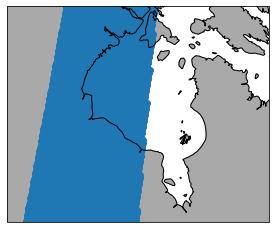

In [9]:
### include west side of bay only, where the bears spend the summer
fig = plt.figure(figsize=(15,5))
spec = gridspec.GridSpec(ncols=3, nrows=2,height_ratios=[5,1],hspace=0.,wspace=0.1)
lons = [-100, -76, -76, -100]
lats = [55,  55,  62,   62]

# plot collars
ax1 = fig.add_subplot(spec[0],projection=ccrs.NorthPolarStereo(central_longitude=-80))
ax1.add_feature(cartopy.feature.OCEAN, color='white', edgecolor='black')
ax1.set_extent([-100, -70, 50, 65], ccrs.PlateCarree())
ax1.add_feature(cartopy.feature.LAND, color='darkgrey',zorder=1)
ax1.scatter(ease_lons[ease_lons<-85],ease_lats[ease_lons<-85],transform=ccrs.PlateCarree())
ax1.coastlines()

In [10]:
datapath_sit = '/Users/carmennab/Dropbox/pb_new/data/SIT/CS2SMOS/'
datapath_sic = '/Users/carmennab/Dropbox/pb_new/data/SIC/'

all_sits = [] ; all_sds = [] ; all_sics = []
first_dates = np.array(first_dates) ; bears = np.array(bears)

for group in [1,2,3]:
    sits = [] ; sds = [] ; sics = []

    for date in set(first_dates[bears==group]):

        filepath_sit = f'{datapath_sit}{date[:4]}/{date}.nc'
        if os.path.exists(filepath_sit) == True: 
            data = Dataset(filepath_sit)
            sd = np.array(data['snow_depth'])
            sit = np.array(data['sea_ice_thickness'])

            for s in sd[(min_ds<100_000) & (~np.isnan(sd) & (ease_lons<-85))]:
                sds.append(s)
            for s in sit[(min_ds<100_000) & (~np.isnan(sit) & (ease_lons<-85))]:
                sits.append(s)

        filepath_sic = f'{datapath_sic}{date[:4]}/{date}.nc'
        if os.path.exists(filepath_sic) == True: 
            data = Dataset(filepath_sic)
            sic = np.array(data['sic'])

            for s in sic[(min_ds<100_000) & (~np.isnan(sic) & (ease_lons<-85))]:
                sics.append(s)
    all_sits.append(sits) ; all_sds.append(sds); all_sics.append(sics)

Ice Thickness
1 MEAN = 0.04
2 MEAN = 0.02
3 MEAN = 0.03
Ice Concentration
1 MEAN = 0.66
2 MEAN = 0.60
3 MEAN = 0.65
Snow Depth
1 MEAN = 0.02
2 MEAN = 0.02
3 MEAN = 0.03


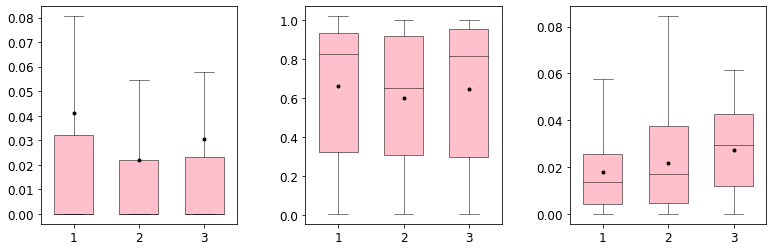

In [11]:
fig = plt.figure(figsize=(13,4))
spec = gridspec.GridSpec(ncols=3,nrows=1,wspace=0.35)
plt.rcParams.update({'font.size': 12})

for c, var in enumerate([all_sits,all_sics,all_sds]):
    print(titles[c])
    ax1 = fig.add_subplot(spec[c])
    box = ax1.boxplot(var, positions=[1,2,3], widths=0.6, patch_artist=True,
            showfliers=False, showmeans = True,
            medianprops={"color": "black", "linewidth": 0.5},
            meanprops={"markerfacecolor": "black","markeredgecolor": "black", "marker": 'o',"markersize":'3'},
            boxprops={"facecolor": 'pink', "edgecolor": "black",
                      "linewidth": 0.5},
            whiskerprops={"color": "black", "linewidth": 0.5},
            capprops={"color": "black", "linewidth": 0.5})
    
    for c,v in enumerate(var):
        print(f'{c+1} MEAN = {np.nanmean(np.array(v)):.2f}')